# 02 - Preprocessing and Feature Extraction

**Objective:** Demonstrate the audio preprocessing pipeline (`preprocessing/audio_preprocess.py`) and feature extraction (`preprocessing/feature_extraction.py`) on a few real example clips, and visualize the resulting MFCC / Mel-spectrogram features.

In [1]:
import sys, os
from pathlib import Path
ML_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ML_ROOT / 'preprocessing'))
sys.path.insert(0, str(ML_ROOT / 'scripts'))
sys.path.insert(0, str(ML_ROOT / 'models'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG_DIR = ML_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('ML_ROOT =', ML_ROOT)


ML_ROOT = /Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml


In [2]:
from feature_extraction import get_feature_extractor
import soundfile as sf
extractor = get_feature_extractor()

`get_feature_extractor()` returns a `FeatureExtractor` configured from `configs/preprocessing.yaml` (16kHz, 13 MFCCs, 40 Mel bins, 512-point FFT, 160-sample hop = 10ms). `.extract_mfcc` / `.extract_mel_spectrogram` operate on a 1D numpy waveform.

## Load one real example per class from the processed v1 manifest

In [3]:
master = pd.read_csv(ML_ROOT / 'datasets' / 'v1' / 'master_v1.csv', low_memory=False)
examples = {}
for cls in ['background', 'chainsaw', 'gunshot']:
    row = master[master['class'] == cls].iloc[0]
    examples[cls] = ML_ROOT / row['processed_path']
examples

{'background': PosixPath('/Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml/datasets/processed/fsc22_2_10201_0000.wav'),
 'chainsaw': PosixPath('/Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml/datasets/processed/fsc22_11_11101_0000.wav'),
 'gunshot': PosixPath('/Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml/datasets/processed/c3gd_16-oh_farm-7mm_Mauser-ALICE-chv3xlV_eY8m-7_0000.wav')}

## Extract and visualize MFCC + Mel-spectrogram for each class

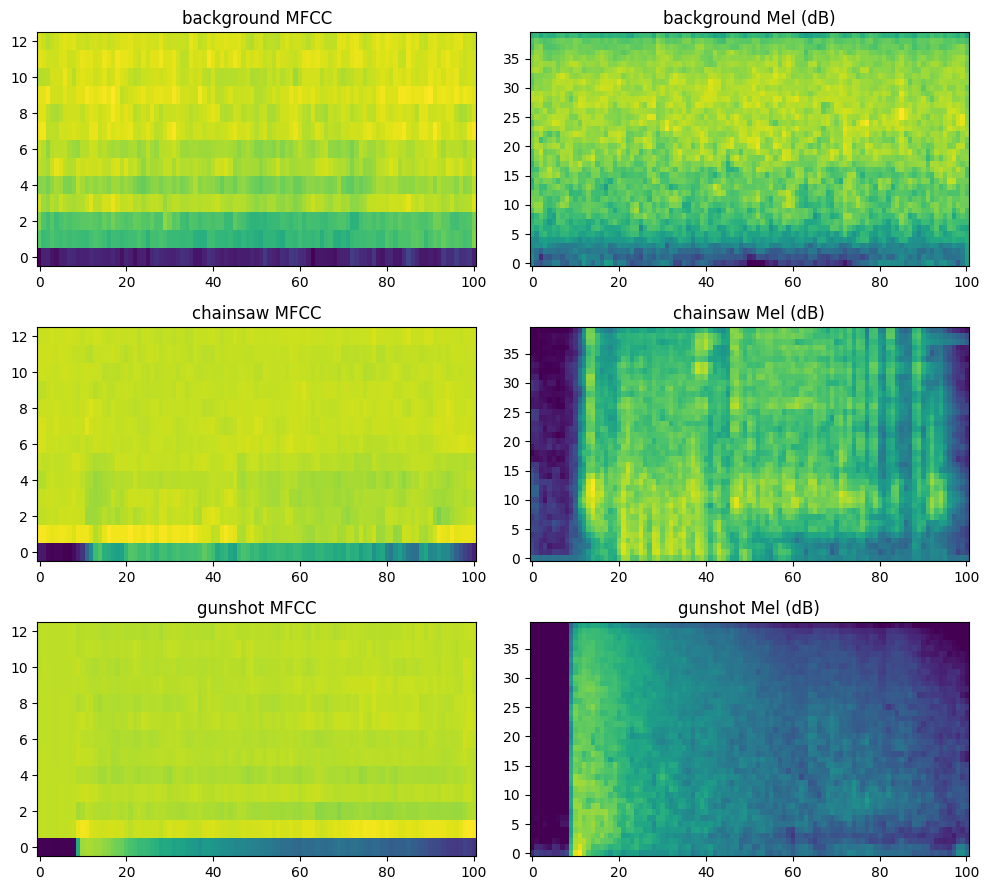

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(10, 9))
for i, (cls, path) in enumerate(examples.items()):
    audio, sr = sf.read(path)
    mfcc = extractor.extract_mfcc(audio, sr)
    mel = extractor.extract_mel_spectrogram(audio, sr)
    axes[i,0].imshow(mfcc, aspect='auto', origin='lower'); axes[i,0].set_title(f'{cls} MFCC')
    axes[i,1].imshow(mel, aspect='auto', origin='lower'); axes[i,1].set_title(f'{cls} Mel (dB)')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_features_by_class.png', dpi=120)
plt.show()

## Digital audio filter: before / after

`apply_filter` (from `preprocessing/audio_filter.py`, the ONE shared implementation used by preprocessing and documented for the ESP32) applies a causal 2nd-order Butterworth high-pass (80 Hz) to the continuous 16 kHz mono stream, before 1 s windowing. Below: its frequency response, then the same frozen-v1 segment without (A) and with (B) the filter (B comes from `datasets/processed_filtered/`, generated by `preprocessing/run_filtered_preprocess.py`).

{'b0': np.float64(0.9780304792065597), 'b1': np.float64(-1.9560609584131194), 'b2': np.float64(0.9780304792065597), 'a1': np.float64(-1.9555782403150352), 'a2': np.float64(0.9565436765112031)}


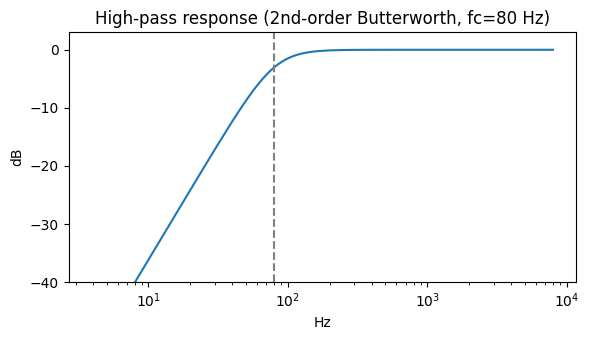

In [5]:
from audio_filter import design_filter, biquad_coefficients
from scipy.signal import sosfreqz
print(biquad_coefficients())
w, h = sosfreqz(design_filter(), worN=2048, fs=16000)
fig, ax = plt.subplots(figsize=(6,3.5))
ax.semilogx(w[1:], 20*np.log10(abs(h[1:]))); ax.axvline(80, ls='--', c='gray')
ax.set_ylim(-40, 3); ax.set_xlabel('Hz'); ax.set_ylabel('dB'); ax.set_title('High-pass response (2nd-order Butterworth, fc=80 Hz)')
plt.tight_layout(); plt.savefig(FIG_DIR/'02_filter_response.png', dpi=120); plt.show()

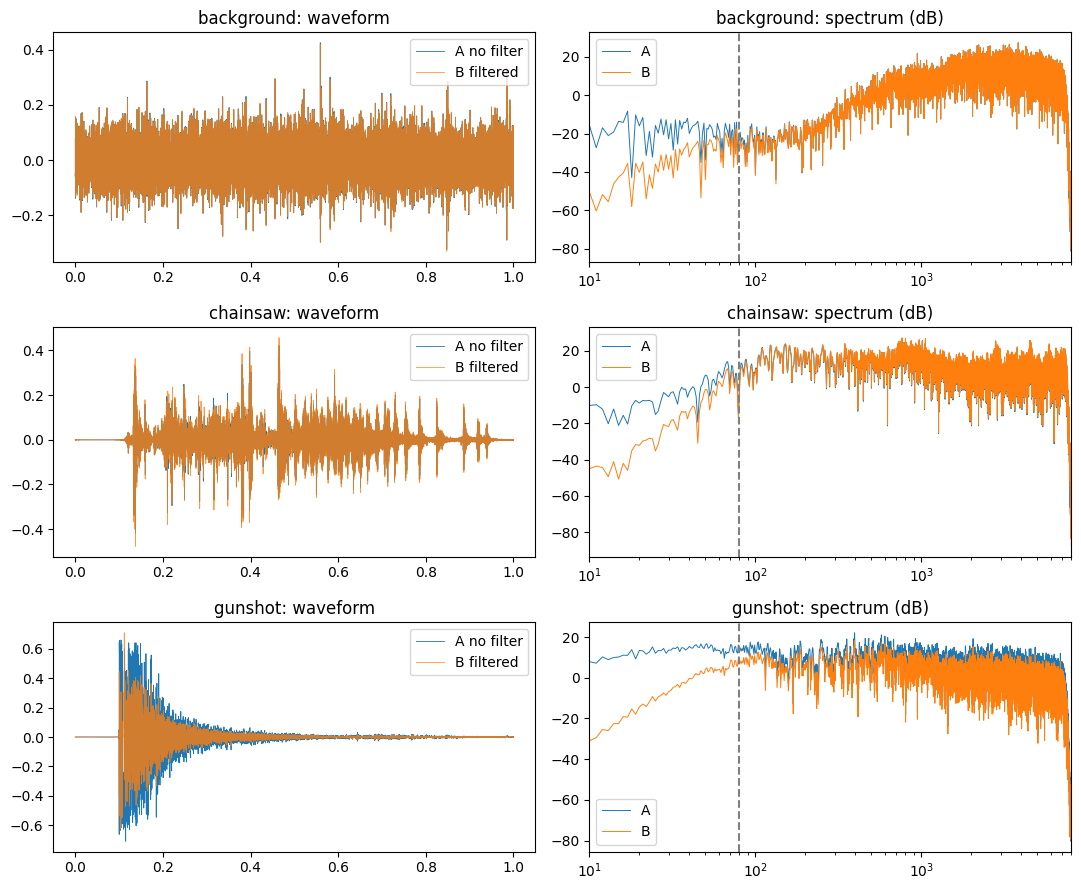

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9))
for i, cls in enumerate(['background', 'chainsaw', 'gunshot']):
    row = master[master['class'] == cls].iloc[0]
    a, sr = sf.read(ML_ROOT / row['processed_path'])
    b, _ = sf.read(ML_ROOT / 'datasets' / 'processed_filtered' / (row['sample_id'] + '.wav'))
    t = np.arange(len(a)) / sr
    axes[i,0].plot(t, a, lw=.6, label='A no filter'); axes[i,0].plot(t, b, lw=.6, alpha=.8, label='B filtered')
    axes[i,0].set_title(f'{cls}: waveform'); axes[i,0].legend(loc='upper right')
    for x, lab in [(a,'A'), (b,'B')]:
        f = np.fft.rfftfreq(len(x), 1/sr); m = 20*np.log10(np.abs(np.fft.rfft(x*np.hanning(len(x))))+1e-9)
        axes[i,1].semilogx(f[1:], m[1:], lw=.7, label=lab)
    axes[i,1].set_title(f'{cls}: spectrum (dB)'); axes[i,1].set_xlim(10, 8000); axes[i,1].axvline(80, ls='--', c='gray'); axes[i,1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'02_filter_before_after.png', dpi=120); plt.show()

## Verify feature shapes match config expectations

In [7]:
shapes = extractor.get_feature_shapes(1.0, 16000)
print('Expected shapes for a 1.0s window at 16kHz:', shapes)

Expected shapes for a 1.0s window at 16kHz: {'mfcc': (13, 97), 'mel_spectrogram': (40, 97)}


## Conclusion

MFCC and Mel-spectrogram features are extracted consistently across classes with a fixed shape (13, 101) and (40, 101) respectively for every 1.0s / 16kHz segment. These are the two feature representations compared for baseline vs CNN modeling in notebooks 04-06.